In [2]:
# load the correlation results
from general_utils import load_temporary_data

# path that you passed as   save_folder / (save_name + ".csv")
zarr_path = "/root/capsule/scratch/correlation_results2/sig_dir_all_sessions.zarr"
ds = load_temporary_data(zarr_path)

print("Rows:", len(ds))
display(ds.head())             # in a notebook


Rows: 69951


,brain_region,ccf_location,fit_metadata,session_id,simple_LR-QLearning_L2F1_softmax-deltaQ-1-g0-s-1-d0-coef,simple_LR-QLearning_L2F1_softmax-deltaQ-1-g0-s-1-d0-pval,simple_LR-QLearning_L2F1_softmax-deltaQ-1-g0-s-1-d0-tval,simple_LR-QLearning_L2F1_softmax-deltaQ-1-g0-s0-d0-coef,simple_LR-QLearning_L2F1_softmax-deltaQ-1-g0-s0-d0-pval,simple_LR-QLearning_L2F1_softmax-deltaQ-1-g0-s0-d0-tval,...,simple_LR-g1-s1-d0-f_stat,simple_LR-g1-s1-d0-hqic,simple_LR-g1-s1-d0-llf,simple_LR-g1-s1-d0-rsq,simple_LR-g1-s1-d0-rsq_adj,simple_LR-g1-s1-d0-sigma2,source_file,time_window,unit_index,z_score
index,,,,,,,,,,,,,,,,,,,,,
0,,"{""best_electrode"": 1, ""shank"": 0, ""probe"": ""Pr...","{""simple_LR-g0-s-1-d0"": {""fit_parameters"": {""a...",753124_2024-12-10_17-24-56,1.377936,2.469676e-25,11.249140,1.366389,6.725340e-25,11.126693,...,0.491740,NaN,-780.199443,0.001376,-0.001422,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,-1_0,9,False
1,,"{""best_electrode"": 1, ""shank"": 0, ""probe"": ""Pr...","{""simple_LR-g0-s-1-d0"": {""fit_parameters"": {""a...",753124_2024-12-10_17-24-56,0.723301,4.905984e-12,7.150996,0.711758,1.031873e-11,7.032964,...,7.052321,NaN,-677.670116,0.019372,0.016625,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2,9,False
2,,"{""best_electrode"": 1, ""shank"": 0, ""probe"": ""Pr...","{""simple_LR-g0-s-1-d0"": {""fit_parameters"": {""a...",753124_2024-12-10_17-24-56,-0.654635,5.907998e-12,-7.121788,-0.654631,5.991041e-12,-7.118902,...,3.552559,NaN,-645.355906,0.009853,0.007080,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2_-1_0,9,False
3,,"{""best_electrode"": 7, ""shank"": 0, ""probe"": ""Pr...","{""simple_LR-g0-s-1-d0"": {""fit_parameters"": {""a...",753124_2024-12-10_17-24-56,1.234634,3.717769e-21,10.069052,1.203877,4.208250e-20,9.758280,...,2.313594,NaN,-770.295057,0.006439,0.003656,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,-1_0,14,False
4,,"{""best_electrode"": 7, ""shank"": 0, ""probe"": ""Pr...","{""simple_LR-g0-s-1-d0"": {""fit_parameters"": {""a...",753124_2024-12-10_17-24-56,1.058975,5.698126e-26,11.423744,1.112609,4.753323e-29,12.248829,...,2.283231,NaN,-680.821971,0.006355,0.003572,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2,14,False


In [3]:
# Define column names
pval_col = "simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-pval"
coef_col = "simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-coef"
pval_col = "simple_LR-QLearning_L2F1_softmax-deltaQ-1-g0-s0-d0-pval"
coef_col = "simple_LR-QLearning_L2F1_softmax-deltaQ-1-g0-s0-d0-coef"
#pval_col = "simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-pval"
#coef_col = "simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-coef"

time_window = "-1_0"
alpha = 0.05
brain_areas = ["SI", "MA"]
#brain_areas = ["MD"]
coef_col_sign = ["negative"]  # can be ["positive"], ["negative"], or both

# Normalize lists
if isinstance(brain_areas, str):
    brain_areas = [brain_areas]

if isinstance(coef_col_sign, str):
    coef_col_sign = [coef_col_sign]

# ---------------------------------------------
# Build the coefficient sign filter
# ---------------------------------------------
sign_mask = True  # default = keep all

if "positive" in coef_col_sign and "negative" not in coef_col_sign:
    sign_mask = ds[coef_col] > 0
elif "negative" in coef_col_sign and "positive" not in coef_col_sign:
    sign_mask = ds[coef_col] < 0
elif "positive" in coef_col_sign and "negative" in coef_col_sign:
    sign_mask = (ds[coef_col] > 0) | (ds[coef_col] < 0)   # i.e., nonzero
else:
    raise ValueError("coef_col_sign must contain 'positive', 'negative', or both.")

# ---------------------------------------------
# Combine masks
# ---------------------------------------------
mask = (
    (ds[pval_col] < alpha) &
    (ds["time_window"] == time_window) &
    (ds["brain_region"].isin(brain_areas)) &
    (sign_mask)
)

# ---------------------------------------------
# Filter rows
# ---------------------------------------------
selected = ds.loc[mask, ["session_id", "unit_index"]]

# Convert formats if needed
result_tuples = list(selected.itertuples(index=False, name=None))
result_dicts = selected.to_dict(orient="records")


In [30]:
len(result_dicts)

179

In [5]:

import importlib
import extract_psth_latent      # ← FIRST import the module
importlib.reload(extract_psth_latent)


from extract_psth_latent import (
    extract_response_psth_and_latent,
    load_response_psth_and_latent_zarr,
    plot_psth_quantiles_from_response_res,
)

# Example latent columns you want to extract from behavior_summary-*.csv
latent_cols = [
    "QLearning_L2F1_softmax-deltaQ-1",
    "QLearning_L2F1_softmax-sumQ-1",
]

save_path = "/root/capsule/scratch/psth_latent_allunits.zarr"

res = extract_response_psth_and_latent(
    unit_specs=result_dicts,
    latent_cols=latent_cols,
    psth_root="/root/capsule/scratch/psth",
    behavior_summary_root="/root/capsule/scratch",
    align_to_event="go_cue",
    time_window=(-3, 5),       # same as your PSTH alignment window
    save_zarr_path=save_path,
)

print("Extracted PSTH shape:", res["psth"].shape)
print("Extracted latent shape:", res["latent_values"].shape)
print("Time bins:", res["time"].shape)


Found behavior NWB: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/769884_2025-01-16_18-33-11.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/769884_2025-01-16_18-33-11.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-14_15-19-17.nwb


KeyboardInterrupt: 

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from extract_psth_latent import (
    load_response_psth_and_latent_zarr,
    plot_psth_quantiles_from_response_res,
)

# -------------------------------------------------
# 1. Load the saved Zarr results
# -------------------------------------------------

zarr_path = "/root/capsule/scratch/psth_latent_allunits.zarr"

res = load_response_psth_and_latent_zarr(zarr_path)

print("Loaded keys:", res.keys())
print("psth shape:", res["psth"].shape)            # (N_total_trials, T)
print("latent shape:", res["latent_values"].shape) # (N_total_trials, L)
print("latent cols:", res["latent_cols"])          # list of names
print("time shape:", res["time"].shape)

# Example:
# psth shape  -> (1240, 150)    # 1240 total (unit,trial) samples
# latent shape-> (1240, 2)      # 2 latent variables


Loaded keys: dict_keys(['time', 'psth', 'latent_values', 'latent_cols'])
psth shape: (99890, 40)
latent shape: (99890, 2)
latent cols: ['QLearning_L2F1_softmax-deltaQ-1', 'QLearning_L2F1_softmax-sumQ-1']
time shape: (40,)


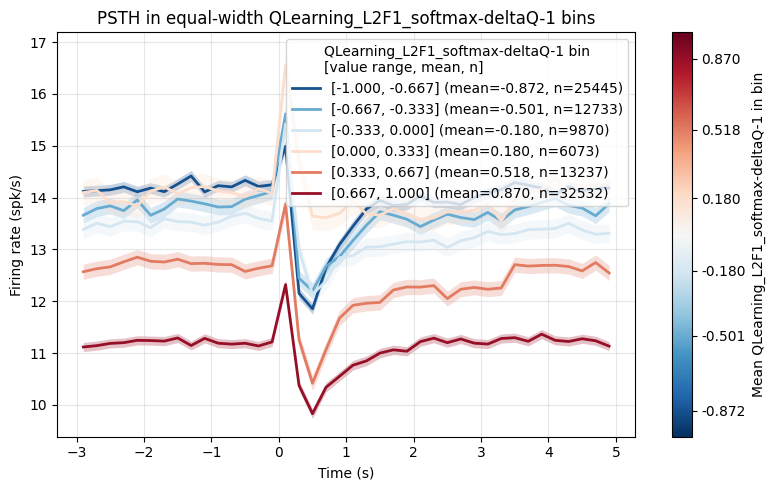

In [33]:
import importlib
import extract_psth_latent      # ← FIRST import the module
importlib.reload(extract_psth_latent)


from extract_psth_latent import (
    extract_response_psth_and_latent,
    load_response_psth_and_latent_zarr,
    plot_psth_quantiles_from_response_res,
)


zarr_path = "/root/capsule/scratch/psth_latent_allunits.zarr"
res = load_response_psth_and_latent_zarr(zarr_path)


plot_psth_quantiles_from_response_res(
    res,
    latent_name="QLearning_L2F1_softmax-deltaQ-1",
    n_quantiles=6,           # quartiles
    sort_ascending=True,
    cmap='RdBu_r'
)
